# Plan 3 — pLDDT vs ESM-2 Advantage (P3-T19)

Renamed from the original spec's `06_rns_analysis.ipynb` per the P3-T6 metric pivot —
the primary structural metric is now mean binding-site pLDDT, not RNS.

## Pre-registered hypothesis (Plan 3 design spec Section 5 / spec 5.2, post-pivot)
- Per-target ESM-FP-MLP-vs-MLP RMSE advantage correlates with per-target
  mean binding-site pLDDT (the AlphaFold-derived structural-confidence proxy).
- Cross-class question: do the slopes differ between kinases and GPCRs?
  Tested via class × pLDDT interaction in `fit_degradation_regression`.

## Inputs
- `data/processed/v1/per_target_plddt.csv` (T14, 543 rows; 303 successful)
- `data/processed/v1/per_target/per_target_{esm_fp_mlp,mlp}_random.csv` (GPCR)
- `data/kinase_reference/benchmark_v1/per_target/per_target_{esm_fp_mlp,mlp}_random.csv` (kinase)

## Outputs
- `results/figures/figure4_plddt_advantage.png`
- `results/tables/04_metric_correlations.csv` (unified: T18 scaffold rows + pLDDT rows)
- `results/supplement/structure_provenance.csv`


In [1]:
"""Plan 3 P3-T19 — pLDDT vs ESM-2 advantage cross-class analysis.

Pre-registered hypothesis (Plan 3 design spec Section 5 / spec 5.2, post-pivot):
  - Per-target ESM-FP-MLP-vs-MLP RMSE advantage correlates with per-target
    mean binding-site pLDDT.
  - Cross-class question: do the slopes differ between kinases and GPCRs?
    Tested via class * pLDDT interaction in fit_degradation_regression.

Inputs:
  data/processed/v1/per_target_plddt.csv                                (T14, 543 rows)
  data/processed/v1/per_target/per_target_{esm_fp_mlp,mlp}_random.csv   (GPCR per-target)
  data/kinase_reference/benchmark_v1/per_target/per_target_{esm_fp_mlp,mlp}_random.csv

Outputs:
  results/figures/figure4_plddt_advantage.png
  results/tables/04_metric_correlations.csv  (appends pLDDT rows to T18's scaffold rows)
  results/supplement/structure_provenance.csv
"""
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from target_affinity_ml.benchmarks.scaffold_diversity import fit_degradation_regression

# Resolve repo root by walking up from CWD looking for pyproject.toml.
# Robust to launch directory (notebooks/ vs repo root).
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
# This notebook compares ESM-2 sequence-embedding model vs structure-free MLP
# (different pair from T18's canonical random_forest baseline).
ESM_MODEL = "esm_fp_mlp"
BASELINE_MODEL = "mlp"
SPLIT = "random"  # primary split where ESM-2 was shown to help in the kinase preprint
print(f"Repo: {REPO_ROOT}")
print(f"Advantage = RMSE({ESM_MODEL}) - RMSE({BASELINE_MODEL}) on {SPLIT} split")


Repo: /Users/joshuaabbott/gpcr-aminergic-benchmarks
Advantage = RMSE(esm_fp_mlp) - RMSE(mlp) on random split


In [2]:
# Load per-target binding-site pLDDT (T14 output).
plddt = pd.read_csv(REPO_ROOT / "data/processed/v1/per_target_plddt.csv")
print(f"Loaded {len(plddt)} per-target pLDDT rows")
print(plddt.groupby("class_name").agg(
    total=("chembl_id", "count"),
    success=("mean_binding_site_plddt", lambda s: s.notna().sum()),
))
plddt.head()


Loaded 543 per-target pLDDT rows
                total  success
class_name                    
gpcr_aminergic     36       36
kinase            507      267


,chembl_id,class_name,uniprot,structure_source,n_binding_residues,mean_binding_site_plddt,error
0,CHEMBL1805,gpcr_aminergic,P30939,AlphaFold,30,92.189667,NaN
1,CHEMBL1821,gpcr_aminergic,P08173,AlphaFold,30,97.696000,NaN
2,CHEMBL1833,gpcr_aminergic,P41595,AlphaFold,30,94.906333,NaN
3,CHEMBL1850,gpcr_aminergic,P21918,AlphaFold,30,88.161333,NaN
4,CHEMBL1867,gpcr_aminergic,P08913,AlphaFold,30,89.529667,NaN


In [3]:
# Compute per-target ESM-2 advantage (RMSE_esm - RMSE_mlp) for each class on random split.
# Negative = ESM-2 helps. Random split is the primary direction where ESM-2 was reported
# to help in the kinase preprint.

def load_advantage_for_class(per_target_dir: Path, class_name: str, split: str = SPLIT) -> pd.DataFrame:
    """Compute per-target ESM_FP_MLP_RMSE - MLP_RMSE on the named split."""
    esm = pd.read_csv(per_target_dir / f"per_target_{ESM_MODEL}_{split}.csv")[
        ["target_id", "rmse"]
    ].rename(
        columns={"target_id": "target_chembl_id", "rmse": "rmse_esm"}
    )
    mlp = pd.read_csv(per_target_dir / f"per_target_{BASELINE_MODEL}_{split}.csv")[
        ["target_id", "rmse"]
    ].rename(
        columns={"target_id": "target_chembl_id", "rmse": "rmse_mlp"}
    )
    df = esm.merge(mlp, on="target_chembl_id", how="inner")
    df["esm_advantage"] = df["rmse_esm"] - df["rmse_mlp"]
    df["class_name"] = class_name
    return df


gpcr_adv = load_advantage_for_class(
    REPO_ROOT / "data/processed/v1/per_target", "gpcr_aminergic"
)
kinase_adv = load_advantage_for_class(
    REPO_ROOT / "data/kinase_reference/benchmark_v1/per_target", "kinase"
)
advantage = pd.concat([gpcr_adv, kinase_adv], ignore_index=True)
print(f"Loaded {len(advantage)} per-target advantage rows ({len(gpcr_adv)} GPCR + {len(kinase_adv)} kinase)")
advantage.head()


Loaded 307 per-target advantage rows (36 GPCR + 271 kinase)


,target_chembl_id,rmse_esm,rmse_mlp,esm_advantage,class_name
0,CHEMBL1805,0.743395,1.166128,-0.422733,gpcr_aminergic
1,CHEMBL1821,0.517225,0.679274,-0.162049,gpcr_aminergic
2,CHEMBL1833,0.633422,0.837837,-0.204415,gpcr_aminergic
3,CHEMBL1850,0.712474,1.152646,-0.440172,gpcr_aminergic
4,CHEMBL1867,0.745652,0.940598,-0.194945,gpcr_aminergic


In [4]:
# Join pLDDT + advantage on chembl_id.
joined = plddt[
    ["chembl_id", "class_name", "uniprot", "n_binding_residues", "mean_binding_site_plddt"]
].merge(
    advantage[["target_chembl_id", "rmse_esm", "rmse_mlp", "esm_advantage"]],
    left_on="chembl_id", right_on="target_chembl_id", how="inner",
).drop(columns="target_chembl_id")
# Drop rows where pLDDT or advantage is NaN.
joined_finite = joined.dropna(subset=["mean_binding_site_plddt", "esm_advantage"])
print(f"Joined: {len(joined)} total, {len(joined_finite)} finite (both pLDDT + advantage available)")
print(joined_finite.groupby("class_name").size())
joined_finite.head()


Joined: 307 total, 239 finite (both pLDDT + advantage available)
class_name
gpcr_aminergic     36
kinase            203
dtype: int64


,chembl_id,class_name,uniprot,n_binding_residues,mean_binding_site_plddt,rmse_esm,rmse_mlp,esm_advantage
0,CHEMBL1805,gpcr_aminergic,P30939,30,92.189667,0.743395,1.166128,-0.422733
1,CHEMBL1821,gpcr_aminergic,P08173,30,97.696000,0.517225,0.679274,-0.162049
2,CHEMBL1833,gpcr_aminergic,P41595,30,94.906333,0.633422,0.837837,-0.204415
3,CHEMBL1850,gpcr_aminergic,P21918,30,88.161333,0.712474,1.152646,-0.440172
4,CHEMBL1867,gpcr_aminergic,P08913,30,89.529667,0.745652,0.940598,-0.194945


In [5]:
# Run the H3 cross-class regression:
#   esm_advantage ~ pLDDT * class_name
# Reports per-class slopes (estimated via the class * metric interaction in OLS)
# and the cross-class interaction p-value.
result = fit_degradation_regression(
    joined_finite,
    metric_col="mean_binding_site_plddt",
    degradation_col="esm_advantage",
    class_col="class_name",
)
print(f"R^2 = {result['r_squared']:.3f}")
print("Per-class slopes:")
for cls, slope_info in result["slopes"].items():
    print(
        f"  {cls}: slope = {slope_info['slope']:+.5f} "
        f"({slope_info['ci_low']:+.5f}, {slope_info['ci_high']:+.5f}), "
        f"p = {slope_info['p_value']:.4f}, n = {result['n_per_class'][cls]}"
    )
print(f"Interaction p = {result['interaction_p']:.4f}")
print(
    "Verdict: "
    + ("differ across classes" if result["interaction_p"] < 0.05 else "consistent across classes")
)


R^2 = 0.562
Per-class slopes:
  gpcr_aminergic: slope = +0.00914 (-0.00011, +0.01839), p = 0.0528, n = 36
  kinase: slope = -0.00137 (-0.00378, +0.00104), p = 0.2634, n = 203
Interaction p = 0.0313
Verdict: differ across classes


In [6]:
# Per-class distribution comparison (KS + Welch) on pLDDT itself.
gpcr_plddt = joined_finite[joined_finite["class_name"] == "gpcr_aminergic"]["mean_binding_site_plddt"]
kinase_plddt = joined_finite[joined_finite["class_name"] == "kinase"]["mean_binding_site_plddt"]

ks = stats.ks_2samp(gpcr_plddt, kinase_plddt)
welch = stats.ttest_ind(gpcr_plddt, kinase_plddt, equal_var=False)
print(f"GPCR pLDDT:   n={len(gpcr_plddt)}, mean={gpcr_plddt.mean():.2f}, std={gpcr_plddt.std():.2f}")
print(f"Kinase pLDDT: n={len(kinase_plddt)}, mean={kinase_plddt.mean():.2f}, std={kinase_plddt.std():.2f}")
print(f"KS test:      D={ks.statistic:.4f}, p={ks.pvalue:.4f}")
print(f"Welch t-test: t={welch.statistic:.3f}, p={welch.pvalue:.4f}")


GPCR pLDDT:   n=36, mean=92.96, std=3.14
Kinase pLDDT: n=203, mean=90.42, std=5.02
KS test:      D=0.2917, p=0.0084
Welch t-test: t=4.024, p=0.0001


In [7]:
# Append pLDDT rows to the unified Table 4 (load T18's scaffold portion + append 3 rows).
scaffold_csv = REPO_ROOT / "results/tables/04_metric_correlations_scaffold.csv"
scaffold_rows = pd.read_csv(scaffold_csv) if scaffold_csv.exists() else pd.DataFrame()
print(f"Loaded {len(scaffold_rows)} scaffold rows from {scaffold_csv.name}")

# Per-class keys: literal class_name values present in the data.
slopes = result["slopes"]
kin_key = "kinase" if "kinase" in slopes else next(iter(slopes))
gpcr_key = (
    "gpcr_aminergic" if "gpcr_aminergic" in slopes else
    ([k for k in slopes if k != kin_key][0] if len(slopes) > 1 else kin_key)
)

# Build the pLDDT regression row in the same schema as scaffold rows.
plddt_row = {
    "direction": "esm_advantage_random",
    "metric": "mean_binding_site_plddt",
    "n_obs": result["n_obs"],
    "n_kinase": result["n_per_class"].get(kin_key),
    "n_gpcr": result["n_per_class"].get(gpcr_key),
    "r_squared": result["r_squared"],
    "intercept": result["intercept"],
    "slope_kinase": slopes[kin_key]["slope"],
    "slope_kinase_p": slopes[kin_key]["p_value"],
    "slope_kinase_ci_low": slopes[kin_key]["ci_low"],
    "slope_kinase_ci_high": slopes[kin_key]["ci_high"],
    "slope_gpcr": slopes[gpcr_key]["slope"],
    "slope_gpcr_p": slopes[gpcr_key]["p_value"],
    "slope_gpcr_ci_low": slopes[gpcr_key]["ci_low"],
    "slope_gpcr_ci_high": slopes[gpcr_key]["ci_high"],
    "interaction_p": result["interaction_p"],
}

# Plus KS + Welch as supplementary distribution rows (slope* slots reused for stat values).
extra_rows = [
    {
        "direction": "plddt_distribution",
        "metric": "ks_2sample",
        "n_obs": len(joined_finite),
        "n_kinase": len(kinase_plddt),
        "n_gpcr": len(gpcr_plddt),
        "r_squared": float("nan"),
        "intercept": float("nan"),
        "slope_kinase": float(ks.statistic),
        "slope_kinase_p": float(ks.pvalue),
        "slope_kinase_ci_low": float("nan"),
        "slope_kinase_ci_high": float("nan"),
        "slope_gpcr": float("nan"),
        "slope_gpcr_p": float("nan"),
        "slope_gpcr_ci_low": float("nan"),
        "slope_gpcr_ci_high": float("nan"),
        "interaction_p": float("nan"),
    },
    {
        "direction": "plddt_distribution",
        "metric": "welch_t",
        "n_obs": len(joined_finite),
        "n_kinase": len(kinase_plddt),
        "n_gpcr": len(gpcr_plddt),
        "r_squared": float("nan"),
        "intercept": float("nan"),
        "slope_kinase": float(welch.statistic),
        "slope_kinase_p": float(welch.pvalue),
        "slope_kinase_ci_low": float("nan"),
        "slope_kinase_ci_high": float("nan"),
        "slope_gpcr": float("nan"),
        "slope_gpcr_p": float("nan"),
        "slope_gpcr_ci_low": float("nan"),
        "slope_gpcr_ci_high": float("nan"),
        "interaction_p": float("nan"),
    },
]

table4 = pd.concat(
    [scaffold_rows, pd.DataFrame([plddt_row, *extra_rows])], ignore_index=True
)
tables_dir = REPO_ROOT / "results/tables"
tables_dir.mkdir(parents=True, exist_ok=True)
table4_path = tables_dir / "04_metric_correlations.csv"
table4.to_csv(table4_path, index=False)
print(f"Wrote unified Table 4 ({len(table4)} rows) to {table4_path}")
table4.tail()


Loaded 10 scaffold rows from 04_metric_correlations_scaffold.csv
Wrote unified Table 4 (13 rows) to /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/tables/04_metric_correlations.csv


,direction,metric,n_obs,n_kinase,n_gpcr,r_squared,intercept,slope_kinase,slope_kinase_p,slope_kinase_ci_low,slope_kinase_ci_high,slope_gpcr,slope_gpcr_p,slope_gpcr_ci_low,slope_gpcr_ci_high,interaction_p
8,delta_scaffold_to_target,mean_tanimoto,29,24,5,0.437876,-0.174992,2.309376,0.000483,1.123322,3.495430,0.763225,0.465480,-1.357525,2.883976,0.201939
9,delta_scaffold_to_target,activity_cliff_frequency,29,24,5,0.106899,-0.037241,46.059956,0.284064,-40.592462,132.712374,-13.715251,0.948959,-450.572939,423.142436,0.784497
10,esm_advantage_random,mean_binding_site_plddt,239,203,36,0.562282,-1.160918,-0.001371,0.263383,-0.003781,0.001038,0.009140,0.052841,-0.000113,0.018394,0.031336
11,plddt_distribution,ks_2sample,239,203,36,NaN,NaN,0.291735,0.008376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,plddt_distribution,welch_t,239,203,36,NaN,NaN,4.024183,0.000141,NaN,NaN,NaN,NaN,NaN,NaN,NaN


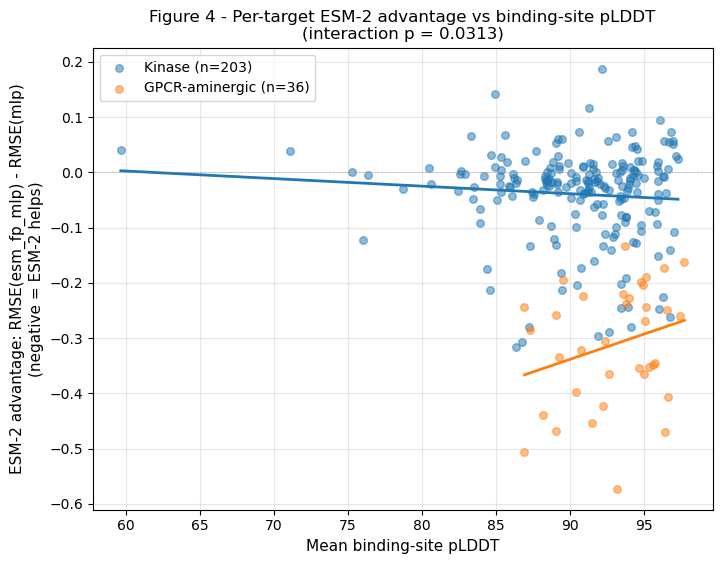

Wrote /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/figures/figure4_plddt_advantage.png


In [8]:
# Figure 4 — scatter of pLDDT vs ESM-2 advantage, colored by class, with per-class regression lines.
fig, ax = plt.subplots(figsize=(8, 6))
class_styles = [
    ("kinase", "tab:blue", "Kinase"),
    ("gpcr_aminergic", "tab:orange", "GPCR-aminergic"),
]

for cls, color, label in class_styles:
    sub = joined_finite[joined_finite["class_name"] == cls]
    if sub.empty:
        continue
    ax.scatter(
        sub["mean_binding_site_plddt"], sub["esm_advantage"],
        alpha=0.5, s=30, color=color, label=f"{label} (n={len(sub)})",
    )
    if len(sub) >= 2:
        x_line = np.linspace(
            sub["mean_binding_site_plddt"].min(), sub["mean_binding_site_plddt"].max(), 50
        )
        # Per-class regression line via polyfit (independent of the pooled OLS intercept logic).
        s_local, i_local = np.polyfit(
            sub["mean_binding_site_plddt"], sub["esm_advantage"], 1
        )
        ax.plot(x_line, s_local * x_line + i_local, color=color, linewidth=2)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_xlabel("Mean binding-site pLDDT", fontsize=11)
ax.set_ylabel(
    "ESM-2 advantage: RMSE(esm_fp_mlp) - RMSE(mlp)\n(negative = ESM-2 helps)",
    fontsize=11,
)
ax.set_title(
    f"Figure 4 - Per-target ESM-2 advantage vs binding-site pLDDT\n"
    f"(interaction p = {result['interaction_p']:.4f})",
    fontsize=12,
)
ax.legend(loc="best", fontsize=10)
ax.grid(alpha=0.3)

figures_dir = REPO_ROOT / "results/figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fig_path = figures_dir / "figure4_plddt_advantage.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig_path}")


In [9]:
# Save structure_provenance.csv (supplementary) — full 543-row table with all classes,
# uniprot, structure_source, n_binding_residues, mean_binding_site_plddt, and any error message.
provenance = plddt[
    [
        "chembl_id", "class_name", "uniprot", "structure_source",
        "n_binding_residues", "mean_binding_site_plddt", "error",
    ]
].copy()
provenance = provenance.rename(columns={"chembl_id": "target_chembl_id"})

supp_dir = REPO_ROOT / "results/supplement"
supp_dir.mkdir(parents=True, exist_ok=True)
prov_path = supp_dir / "structure_provenance.csv"
provenance.to_csv(prov_path, index=False)
print(f"Wrote structure provenance ({len(provenance)} rows) to {prov_path}")

# Coverage summary.
print("\n=== Coverage by class x structure_source ===")
print(provenance.groupby(["class_name", "structure_source"]).size().unstack(fill_value=0))
print("\n=== Most common error reasons ===")
print(provenance["error"].value_counts(dropna=False).head())


Wrote structure provenance (543 rows) to /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/supplement/structure_provenance.csv

=== Coverage by class x structure_source ===
structure_source  AlphaFold
class_name                 
gpcr_aminergic           36
kinase                  505

=== Most common error reasons ===
error
NaN                                                                   304
no binding site (API returned empty list)                             237
fetch_structure failed: AlphaFold API returned HTTP 404 for P78527      1
fetch_structure failed: AlphaFold API returned HTTP 404 for Q13315      1
Name: count, dtype: int64


In [10]:
# Interpretation summary.
print("=== H3 finding: ESM-2 advantage vs pLDDT ===\n")
print(f"Total per-target observations (both metrics finite): {len(joined_finite)}")
print(
    f"  GPCR  (n={result['n_per_class'].get(gpcr_key)}): "
    f"slope = {slopes[gpcr_key]['slope']:+.5f}, p = {slopes[gpcr_key]['p_value']:.4f}"
)
print(
    f"  Kinase (n={result['n_per_class'].get(kin_key)}): "
    f"slope = {slopes[kin_key]['slope']:+.5f}, p = {slopes[kin_key]['p_value']:.4f}"
)
print(f"  Cross-class interaction p = {result['interaction_p']:.4f}  ->  ", end="")
if result["interaction_p"] < 0.05:
    print("SIGNIFICANT - ESM-2 advantage depends on pLDDT differently in kinases vs GPCRs.")
else:
    print("NOT significant - no detectable cross-class slope difference.")

print("\n=== Per-class pLDDT distribution comparison ===")
print(f"KS p   = {ks.pvalue:.4f}  -> distributions {'differ' if ks.pvalue < 0.05 else 'similar'}")
print(f"Welch p = {welch.pvalue:.4f} -> means {'differ' if welch.pvalue < 0.05 else 'similar'}")
print(f"GPCR  pLDDT mean = {gpcr_plddt.mean():.2f} +/- {gpcr_plddt.std():.2f}")
print(f"Kinase pLDDT mean = {kinase_plddt.mean():.2f} +/- {kinase_plddt.std():.2f}")


=== H3 finding: ESM-2 advantage vs pLDDT ===

Total per-target observations (both metrics finite): 239
  GPCR  (n=36): slope = +0.00914, p = 0.0528
  Kinase (n=203): slope = -0.00137, p = 0.2634
  Cross-class interaction p = 0.0313  ->  SIGNIFICANT - ESM-2 advantage depends on pLDDT differently in kinases vs GPCRs.

=== Per-class pLDDT distribution comparison ===
KS p   = 0.0084  -> distributions differ
Welch p = 0.0001 -> means differ
GPCR  pLDDT mean = 92.96 +/- 3.14
Kinase pLDDT mean = 90.42 +/- 5.02
